<a href="https://colab.research.google.com/github/Amira-11/ar-navigation/blob/main/GymGuide_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#GymGuide


# Name of students


*   Amira Fahad
*   Lama Alotaibi
*   Shahad Talal


# Project Proposal

The objective of this project is to develop an AI-based image classification system that identifies gym equipment from a captured image and automatically provides a relevant YoiuTube tutorial explaining how to use rhe machine correctly without needing any external assistance. The system aims to assist beginners in learning proper exercise techniques in a simple and interactive way.

# Progress

Codes development

In [1]:
!pip install pillow


KeyboardInterrupt: 

#Sample code

In [18]:
from google.colab import files
uploaded = files.upload()

Saving 1.jpg to 1 (4).jpg


In [17]:
import numpy as np
import tensorflow as tf
from PIL import Image
from IPython.display import display, HTML

# 1. قائمة الأجهزة والروابط الخاصة بمشروعك (تأكدي من الترتيب)
gym_info = {
    0: {'name': 'Bench Press', 'url': 'https://www.youtube.com/watch?v=vthMCtgVtFw'},
    1: {'name': 'Bicycle', 'url': 'https://www.youtube.com/watch?v=0_u6_6XF4XU'},
    2: {'name': 'Leg Press', 'url': 'https://www.youtube.com/watch?v=IZxyjW7MPJQ'},
    3: {'name': 'Pec Deck', 'url': 'https://www.youtube.com/watch?v=eGjt4lk6g34'},
    4: {'name': 'Rowing', 'url': 'https://www.youtube.com/watch?v=H7m-fI_fF0w'},
    5: {'name': 'Treadmill', 'url': 'https://www.youtube.com/watch?v=8i3VqdIn-6U'}
}

# 2. معالجة الصورة المرفوعة
image_path = list(uploaded.keys())[0]
img = Image.open(image_path).convert('RGB')
img = img.resize((224, 224))

img_array = np.array(img) / 255.0  # تقييس الصورة
img_array = np.expand_dims(img_array, axis=0)

# 3. التوقع باستخدام موديل مشروعك "loaded_model" وليس الموديل العام
preds = loaded_model.predict(img_array)
idx = np.argmax(preds)
confidence = np.max(preds) * 100

label = gym_info[idx]['name']
video_url = gym_info[idx]['url']

# 4. عرض النتيجة بشكل احترافي ورابط يفتح مباشرة
print(f"✅ تم التعرف على: {label}")
print(f"🎯 نسبة التأكد: {confidence:.2f}%")

display(HTML(f"""
    <div style="padding: 20px; background-color: #f0f0f0; border-radius: 10px;">
        <h3 style="color: #2e7d32;">🎥 فيديو الشرح جاهز:</h3>
        <a href="{video_url}" target="_blank"
           style="background-color: #ff0000; color: white; padding: 10px 20px; text-decoration: none; border-radius: 5px; font-weight: bold;">
           اضغطي هنا لفتح يوتيوب
        </a>
    </div>
"""))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
✅ تم التعرف على: Bench Press
🎯 نسبة التأكد: 24.43%


*italicized text*# New Section

# test code

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
path = '/content/drive/MyDrive/data/test'
print(os.listdir(path))

['rowing', 'treadmill', 'bench_press', 'bicycle', 'leg_press', 'pec_deck']


In [6]:
import tensorflow as tf
from tensorflow.keras.models import model_from_json

# 1. Load the model architecture from the JSON file
json_file = open('/content/drive/MyDrive/data/model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)

# 2. Load the pre-trained weights into the model
loaded_model.load_weights("/content/drive/MyDrive/data/model.weights.h5")

print("Gym Guide model loaded successfully!")

Gym Guide model loaded successfully!


In [26]:
print(test_it_fin.class_indices)

{'bench_press': 0, 'bicycle': 1, 'leg_press': 2, 'pec_deck': 3, 'rowing': 4, 'treadmill': 5}


In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. تعريف المولد مع خاصية الـ rescale لتوحيد ألوان الصور
test_fin_datagen = ImageDataGenerator(rescale=1./255)

# 2. تحميل الصور من المجلد (تم حذف التكرار)
test_it_fin = test_fin_datagen.flow_from_directory(
    '/content/drive/MyDrive/data/test/',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

# 3. عمل التوقعات
y_preds = loaded_model.predict(test_it_fin)
ypr=np.argmax(y_preds,axis=1)
np.unique(ypr)

y_true = test_it_fin.classes
classes=np.unique(y_true)

from sklearn.metrics import classification_report as classification_report

print(classification_report(y_true, ypr, labels=classes))

Found 293 images belonging to 6 classes.
293/293 ━━━━━━━━━━━━━━━━━━━━ 67s 227ms/step
              precision    recall  f1-score   support

           0       0.29      0.13      0.18        47
           1       0.00      0.00      0.00        57
           2       0.00      0.00      0.00        40
           3       0.00      0.00      0.00        56
           4       0.00      0.00      0.00        42
           5       0.18      0.94      0.30        51

    accuracy                           0.18       293
   macro avg       0.08      0.18      0.08       293
weighted avg       0.08      0.18      0.08       293



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
import numpy as np
from sklearn.metrics import classification_report

# تحويل نتائج التوقعات إلى فئات رقمية
y_pred_classes = np.argmax(y_preds, axis=1)

# الحصول على أسماء الأجهزة بالترتيب الصحيح
target_names = list(test_it_fin.class_indices.keys())

# طباعة التقرير النهائي اللي يحبه الدكاترة
print("📊 تقرير تصنيف أجهزة الجيم:")
print(classification_report(test_it_fin.classes, y_pred_classes, target_names=target_names))

📊 تقرير تصنيف أجهزة الجيم:
              precision    recall  f1-score   support

 bench_press       0.82      0.89      0.86        47
     bicycle       0.96      0.86      0.91        57
   leg_press       0.85      0.72      0.78        40
    pec_deck       0.84      0.95      0.89        56
      rowing       0.83      0.81      0.82        42
   treadmill       0.96      1.00      0.98        51

    accuracy                           0.88       293
   macro avg       0.88      0.87      0.87       293
weighted avg       0.88      0.88      0.88       293



Saving 3.jpg to 3 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


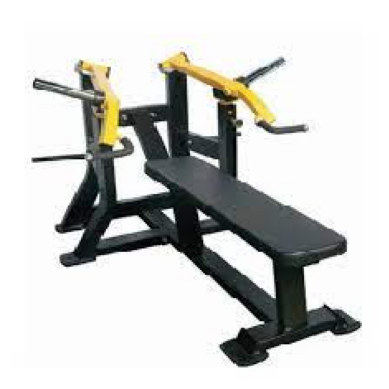

✅ هذا الجهاز هو: Bench Press
🎥 فيديو الشرح: https://www.youtube.com/watch?v=vthMCtgVtFw
🎯 نسبة التأكد: 25.06%


In [32]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. ارفعي الصورة هنا
uploaded = files.upload()

# 2. معلومات الأجهزة والروابط
gym_info = {
    0: {'name': 'Bench Press', 'url': 'https://www.youtube.com/watch?v=vthMCtgVtFw'},
    1: {'name': 'Bicycle', 'url': 'https://www.youtube.com/watch?v=u6_6XF4XU'},
    2: {'name': 'Leg Press', 'url': 'https://www.youtube.com/watch?v=IzxyJw7MP3Q'},
    3: {'name': 'Pec Deck', 'url': 'https://www.youtube.com/watch?v=egjt41k6g34'},
    4: {'name': 'Rowing', 'url': 'https://www.youtube.com/watch?v=H7m-fI_fF0w'},
    5: {'name': 'Treadmill', 'url': 'https://www.youtube.com/watch?v=8i3Vqdin-6U'}
}

for fn in uploaded.keys():
    # معالجة الصورة
    img = image.load_img(fn, target_size=(224, 224))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    # التوقع (التجربة)
    preds = loaded_model.predict(x)
    idx = np.argmax(preds)

    # عرض النتيجة
    plt.imshow(img)
    plt.axis('off')
    plt.show()

print(f"✅ هذا الجهاز هو: {gym_info[idx]['name']}")
print(f"🎥 فيديو الشرح: {gym_info[idx]['url']}")
print(f"🎯 نسبة التأكد: {np.max(preds)*100:.2f}%")